# Análise de Resultados - PUMA FL
Este notebook processa as múltiplas simulações (runs) geradas pelo servidor e plota as curvas de performance comparando diferentes estratégias, exibindo o intervalo de confiança (desvio padrão).

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Configuração de estilo para gráficos nível artigo acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5
})

# Caminho padrão para a pasta de resultados (ajuste se necessário)
RESULTS_DIR = "../results/"

In [8]:
def load_strategy_results(dataset, strategy, algo="FedAVG", prune="withou_Prune"):
    """
    Busca os arquivos h5 gerados pelo servidor e calcula média e desvio padrão.
    """
    # Adicionando o {strategy} de volta ao padrão de busca
    pattern = os.path.join(RESULTS_DIR, f"{dataset}_{strategy}_{prune}_{algo}_run*.h5")
    files = glob.glob(pattern)
    
    if not files:
        print(f"⚠️ Nenhum arquivo encontrado para: {pattern}")
        return None
        
    print(f"✅ Encontrados {len(files)} arquivos para o padrão: {dataset}_{strategy}_{prune}_{algo}")
    
    acc_runs, loss_runs, mb_runs, mb_bruto_runs, time_runs = [], [], [], [], []
    
    for f in files:
        with h5py.File(f, 'r') as hf:
            acc_runs.append(np.array(hf['rs_test_acc']))
            loss_runs.append(np.array(hf['rs_train_loss']))
            mb_runs.append(np.array(hf['sended_model_Mb']))
            mb_bruto_runs.append(np.array(hf['Sended_without_quant']))
            time_runs.append(np.array(hf['Round_time']))
            
    return {
        'acc_mean': np.mean(acc_runs, axis=0), 'acc_std': np.std(acc_runs, axis=0),
        'loss_mean': np.mean(loss_runs, axis=0), 'loss_std': np.std(loss_runs, axis=0),
        'mb_mean': np.mean(mb_runs, axis=0), 'mb_std': np.std(mb_runs, axis=0),
        'mb_bruto_mean': np.mean(mb_bruto_runs, axis=0), 'mb_bruto_std': np.std(mb_bruto_runs, axis=0),
        'time_mean': np.mean(time_runs, axis=0), 'time_std': np.std(time_runs, axis=0),
    }

In [ ]:
DATASET = "OxfordPets"

print("Carregando resultados do Servidor...")

dados_sora = load_strategy_results(
    dataset=DATASET, 
    strategy="sora_with_schedule", # Agora passamos a estratégia correta!
    algo="FedAVG",                
    prune="prune"                  
)

dados_lora = load_strategy_results(
    dataset=DATASET, 
    strategy="lora", # Agora passamos a estratégia correta!
    algo="FedAVG",                
    prune="prune"                  
)

Carregando resultados do Servidor...
✅ Encontrados 2 arquivos para o padrão: OxfordPets_sora_with_schedule_prune_FedAVG
⚠️ Nenhum arquivo encontrado para: ../results/OxfordPets_with_lora_prune_FedAVG_run*.h5


### 1. Desempenho do Modelo (Acurácia Global)

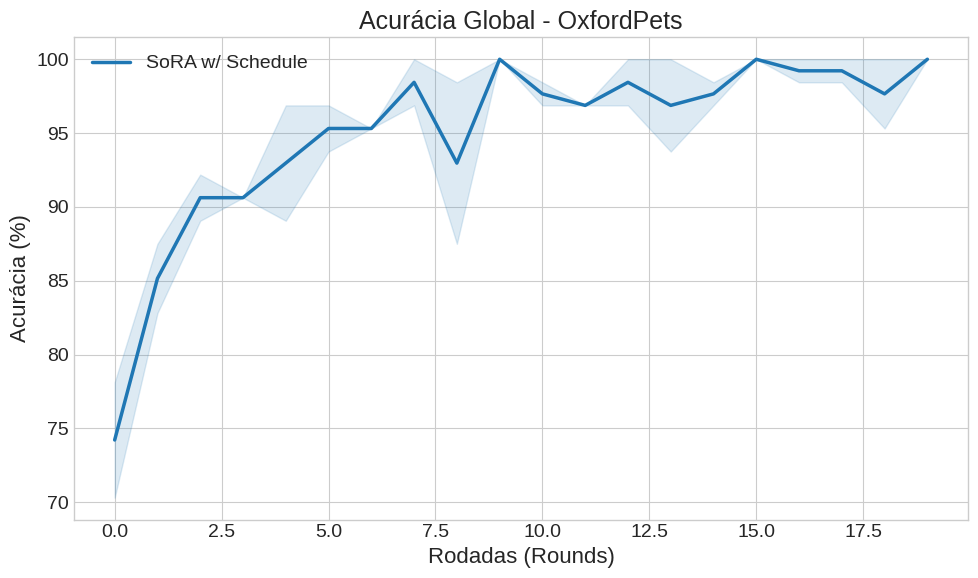

In [10]:
plt.figure(figsize=(10, 6))

if dados_sora:
    plt.plot(dados_sora['acc_mean'], label='SoRA w/ Schedule', color='#1f77b4')
    plt.fill_between(range(len(dados_sora['acc_mean'])), 
                     dados_sora['acc_mean'] - dados_sora['acc_std'], 
                     dados_sora['acc_mean'] + dados_sora['acc_std'], color='#1f77b4', alpha=0.15)

plt.title(f"Acurácia Global - {DATASET}")
plt.xlabel("Rodadas (Rounds)")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.tight_layout()
plt.show()

### 2. Custo de Comunicação Acumulado (Megabytes)

[ 0.          0.68091297  1.36182594  2.04273891  2.72365189  3.40456486
  4.08547783  4.76272631  5.43997478  6.11722326  6.79447174  7.47172022
  8.1489687   8.81888819  9.48880768 10.15872717 10.82864666 11.49856615
 12.16848564 12.83254194 13.49659824 14.16065454 14.82471085 15.48876715
 16.15282345 16.80734348 17.46186352 18.11638355 18.77090359 19.42542362
 20.07994366 20.72347021 21.36699677 22.01052332 22.65404987 23.29757643
 23.94110298 24.57363605 25.20616913 25.8387022  26.47123528]


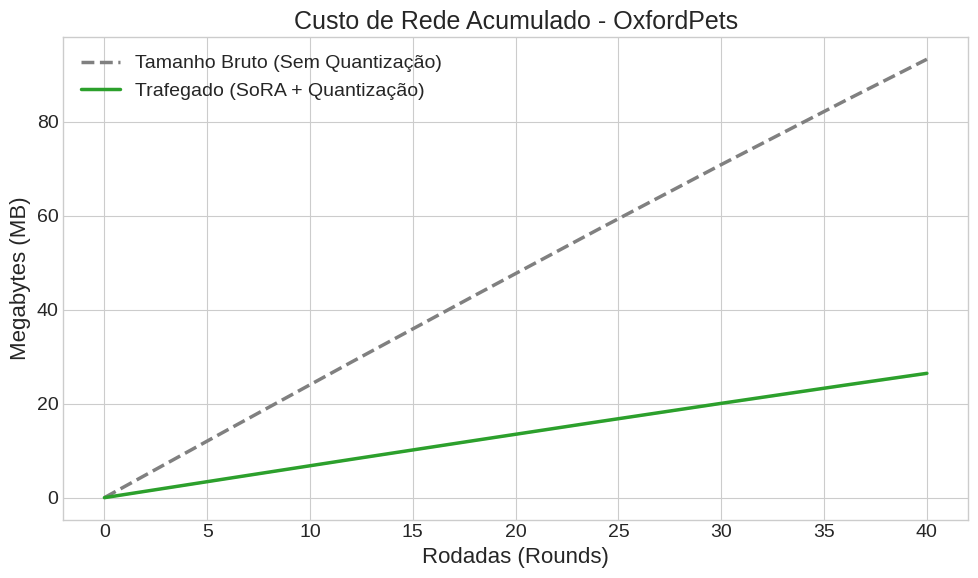

In [11]:

plt.figure(figsize=(10, 6))

if dados_sora:
    eixo_x = range(len(dados_sora['mb_mean']))
    
    # Linha mostrando o tamanho se enviasse o modelo bruto (Sem compressão/quantização)
    plt.plot(eixo_x, dados_sora['mb_bruto_mean'], label='Tamanho Bruto (Sem Quantização)', color='gray', linestyle='--')
    
    # Linha mostrando o que foi efetivamente trafegado com o Framework PUMA
    plt.plot(eixo_x, dados_sora['mb_mean'], label='Trafegado (SoRA + Quantização)', color='#2ca02c')
    
    print(dados_sora['mb_mean'])
    
    # Intervalo de confiança para os dados trafegados
    plt.fill_between(eixo_x, 
                     dados_sora['mb_mean'] - dados_sora['mb_std'], 
                     dados_sora['mb_mean'] + dados_sora['mb_std'], 
                     color='#2ca02c', alpha=0.15)

plt.title(f"Custo de Rede Acumulado - {DATASET}")
plt.xlabel("Rodadas (Rounds)")
plt.ylabel("Megabytes (MB)")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Latência de Treinamento (Tempo)

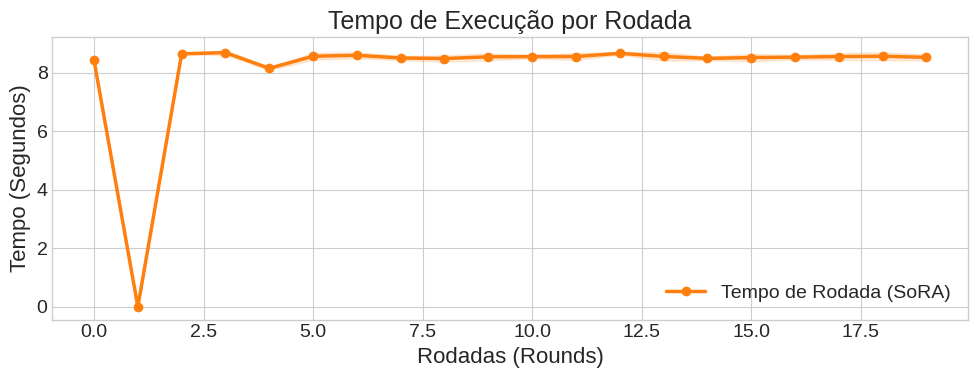

In [12]:

plt.figure(figsize=(10, 4))

if dados_sora:
    eixo_x = range(len(dados_sora['time_mean']))
    plt.plot(eixo_x, dados_sora['time_mean'], label='Tempo de Rodada (SoRA)', color='#ff7f0e', marker='o')
    
    # Intervalo de confiança (Desvio padrão entre as simulações/runs)
    plt.fill_between(eixo_x, 
                     dados_sora['time_mean'] - dados_sora['time_std'], 
                     dados_sora['time_mean'] + dados_sora['time_std'], 
                     color='#ff7f0e', alpha=0.15)

plt.title("Tempo de Execução por Rodada")
plt.xlabel("Rodadas (Rounds)")
plt.ylabel("Tempo (Segundos)")
plt.legend()
plt.tight_layout()
plt.show()